# CardioGNN – Explainability

Three complementary explanation families:

| # | Method | What it explains | Library |
|---|--------|-----------------|---------|
| A | **GNNExplainer** (local) | Which ontology edges/nodes drove *this patient's* prediction | `torch_geometric.explain` |
| B | **Attention analysis** (structural) | Which concept relationships the model attends to *on average* | built-in |
| C | **Integrated Gradients** (input attribution) | Which past events in the sequence contributed most | `captum` |

All artefacts produced by `train.py` are loaded here; no re-training needed.

## 1. Imports and Setup

In [1]:
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATv2Conv
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.data import Data

from captum.attr import IntegratedGradients

warnings.filterwarnings("ignore")

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PLOTS   = Path("outputs/plots/explain")
PLOTS.mkdir(parents=True, exist_ok=True)

# ── Shared graph drawing helper ───────────────────────────────────────────────
# Used by every network plot in this notebook so style is consistent.
#
# Nodes: red for MI-related concepts, green for cardiac/angina, blue otherwise.
# Labels: black, drawn OUTSIDE the node so they never overlap the circle fill.
# Edges: uniform thin width (1.8 pt), coloured blue→yellow→red by weight,
#        with a colorbar legend.  Self-loops are silently skipped.



c:\Users\marti\Desktop\ST-GNN-Comp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define Config before loading the pickle — pickle needs the class in scope
# to deserialise it. If the saved artefact used vars(cfg) (plain dict) this
# block is still harmless.
from dataclasses import dataclass

@dataclass
class Config:
    GRAPH_PATH          : str   = r"data/processed/ontology_graph.pkl"
    COHORT_PATH         : str   = r"data/processed/omop_cohort.pkl"
    OUTPUT_DIR          : str   = "outputs"
    TARGET_CONCEPT_ID   : int   = 4329847
    TARGET_CONCEPT_NAME : str   = "Myocardial infarction"
    EMBED_MODEL         : str   = "pritamdeka/S-PubMedBert-MS-MARCO"
    HIDDEN_DIM          : int   = 32
    GAT_LAYERS          : int   = 2
    GAT_HEADS           : int   = 2
    DEMO_DIM            : int   = 0
    DROPOUT             : float = 0.25
    SEED                : int   = 42
    EPOCHS              : int   = 300
    BATCH_SIZE          : int   = 32
    LR                  : float = 1e-3
    PATIENCE            : int   = 30
    THRESHOLD_FALLBACK  : float = 0.50
    MAX_SEQ_LEN         : int   = 50

In [3]:
def draw_ontology_graph(sub: "nx.DiGraph",
                        weight_key: str = "weight",
                        title: str = "",
                        figsize: tuple = (14, 9),
                        colorbar_label: str = "Edge importance",
                        save_path=None):
    fig, ax = plt.subplots(figsize=figsize)

    self_loops = list(nx.selfloop_edges(sub))
    sub.remove_edges_from(self_loops)

    if sub.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No edges to display", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=220, bbox_inches="tight")
        plt.show()
        return

    try:
        pos = nx.kamada_kawai_layout(sub, scale=4.0)
    except Exception:
        pos = nx.spring_layout(sub, seed=42, k=3.0, scale=4.0)

    # Iterative overlap repulsion
    min_dist = 2.52
    node_list = list(pos.keys())
    for _ in range(120):
        moved = False
        for i in range(len(node_list)):
            for j in range(i + 1, len(node_list)):
                ni, nj = node_list[i], node_list[j]
                xi, yi = pos[ni]
                xj, yj = pos[nj]
                ddx, ddy = xi - xj, yi - yj
                d = (ddx**2 + ddy**2) ** 0.5
                if d < min_dist and d > 1e-6:
                    push = (min_dist - d) / 2.0
                    pos[ni] = (xi + ddx / d * push, yi + ddy / d * push)
                    pos[nj] = (xj - ddx / d * push, yj - ddy / d * push)
                    moved = True
        if not moved:
            break

    _nudge = {
        "Alzheimer's disease"        : (0.08,  -0.4),
        "Acute myocardial infarction": ( 0.08, -0.05),
        "Malignant neoplasm of bronchus" : (2.5, 0.18),
        "Primary malignant neoplasm" : (-1.5, 0.18),
        "Type 2 diabetes mellitus": (0.5, 0.58),
        "CDI":(0,-1)
    }
    for node, (dx, dy) in _nudge.items():
        if node in pos:
            pos[node] = (pos[node][0] + dx, pos[node][1] + dy)

    def node_color(name):
        n = name.lower()
        if any(k in n for k in ["myocardial", "infarction", "cerebral infarc"]):
            return "#c0392b"
        if any(k in n for k in ["angina", "heart", "cardiac", "coronary", "ischemic"]):
            return "#27ae60"
        return "#2980b9"

    node_colors = [node_color(n) for n in sub.nodes()]

    weights  = np.array([sub[u][v].get(weight_key, 0.0) for u, v in sub.edges()])
    w_min, w_max = weights.min(), weights.max()
    w_norm   = (weights - w_min) / (w_max - w_min + 1e-9)
    cmap     = plt.cm.RdYlBu_r
    edge_colors = cmap(w_norm)

    nx.draw_networkx_nodes(sub, pos, ax=ax,
                           node_color=node_colors, node_size=2800, alpha=0.92)

    for (u, v), color in zip(sub.edges(), edge_colors):
        nx.draw_networkx_edges(
            sub, pos, ax=ax,
            edgelist=[(u, v)],
            edge_color=[color],
            width=2.0,
            arrows=True,
            arrowsize=16,
            connectionstyle="arc3,rad=0.12",
            min_source_margin=25,
            min_target_margin=25,
        )

    nx.draw_networkx_labels(sub, pos, ax=ax,
                            font_size=11,
                            font_color="black",
                            font_weight="bold",
                            verticalalignment="bottom",
                            bbox=dict(boxstyle="round,pad=0.18",
                                      fc="white", ec="none", alpha=0.75))

    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=w_min, vmax=w_max))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.01, shrink=0.5, label=colorbar_label)

    ax.set_title(title, fontsize=11, pad=12)
    ax.axis("off")

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_pad = (xmax - xmin) * 0.20
    y_pad = (ymax - ymin) * 0.20
    ax.set_xlim(xmin - x_pad, xmax + x_pad)
    ax.set_ylim(ymin - y_pad, ymax + y_pad)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    return fig

In [4]:
# Load training artefacts ---------------------------------------------------
with open("outputs/cardiognn_config.pkl", "rb") as f:
    art = pickle.load(f)

# Support both old format (Config dataclass) and new format (plain dict)
_cfg_raw = art["config"]
if isinstance(_cfg_raw, dict):
    cfg = Config(**_cfg_raw)
else:
    cfg = _cfg_raw   # already a dataclass instance

concept2idx  = art["concept2idx"]
idx2concept  = art["idx2concept"]
id2name      = art["id2name"]
NUM_CONCEPTS = art["num_concepts"]
PAD_IDX      = art["pad_idx"]
EMBED_DIM    = art["embed_dim"]
BEST_THR     = art.get("best_thr_f2", art.get("best_thr_f1", 0.5))  # prefer F2

C, T, L, Y     = art["C"], art["T"], art["L"], art["Y"]
idx_test       = art["idx_test"]

C_test        = torch.tensor(C[idx_test], dtype=torch.long)
T_test        = torch.tensor(T[idx_test], dtype=torch.float32)
L_test        = torch.tensor(L[idx_test], dtype=torch.long)
Y_test        = torch.tensor(Y[idx_test], dtype=torch.float32)
PAD_MASK_test = (C_test == PAD_IDX)
DEMO_test     = torch.zeros(len(Y_test), cfg.DEMO_DIM, dtype=torch.float32)

print(f"Test patients : {len(Y_test):,}")
print(f"Positives     : {int(Y_test.sum()):,}")
print(f"BEST_THR      : {BEST_THR:.3f}  (F2 primary)")

TypeError: Config.__init__() got an unexpected keyword argument 'TIME2VEC_K'

## 2. Rebuild Model and Load Weights

In [ ]:
# --- Reproduce model definition (must match train.py exactly) ---

from sentence_transformers import SentenceTransformer

with open(cfg.GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

concept_names = [
    id2name.get(idx2concept[i], str(idx2concept[i]))
    for i in range(NUM_CONCEPTS)
]
embedder = SentenceTransformer(cfg.EMBED_MODEL)
CONCEPT_EMBEDDINGS_RAW = embedder.encode(
    concept_names, convert_to_tensor=True,
    show_progress_bar=False, device=str(DEVICE),
).float().to(DEVICE)

# Build EDGE_INDEX (bidirectional) -----------------------------------------
src, dst = [], []
for u, v in G.edges():
    src += [concept2idx[u], concept2idx[v]]
    dst += [concept2idx[v], concept2idx[u]]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long).to(DEVICE)


# Paste model classes from train.py or import them if refactored to a module
class ContinuousTimeEmbedding(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Linear(1, hidden_dim)
    def forward(self, time_seqs):
        return torch.sin(self.proj(time_seqs.unsqueeze(-1)))


class OntologyEncoder(nn.Module):
    def __init__(self, raw_embeddings, embed_dim, hidden_dim, heads, dropout):
        super().__init__()
        self.register_buffer("raw_embed", raw_embeddings.detach().clone())
        self.proj  = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.drop  = nn.Dropout(dropout)
        dim_per_head = hidden_dim // heads
        self.conv1 = GATv2Conv(hidden_dim, dim_per_head, heads=heads, dropout=dropout, add_self_loops=True)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, dim_per_head, heads=heads, dropout=dropout, add_self_loops=True)
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, edge_index, return_attn=False):
        x0 = F.gelu(self.proj(self.raw_embed))
        if return_attn:
            out1, (ei1, a1) = self.conv1(x0, edge_index, return_attention_weights=True)
        else:
            out1 = self.conv1(x0, edge_index); ei1 = a1 = None
        x1 = self.norm1(self.drop(F.gelu(out1)) + x0)
        if return_attn:
            out2, (ei2, a2) = self.conv2(x1, edge_index, return_attention_weights=True)
        else:
            out2 = self.conv2(x1, edge_index); ei2 = a2 = None
        x2 = self.norm2(self.drop(F.gelu(out2)) + x1)
        return (x2, [(ei1, a1), (ei2, a2)]) if return_attn else x2


class CardioGNN(nn.Module):
    def __init__(self, raw_embeddings, embed_dim, hidden_dim, gat_heads, dropout):
        super().__init__()
        self.ontology_enc  = OntologyEncoder(raw_embeddings, embed_dim, hidden_dim, gat_heads, dropout)
        self.time_enc      = ContinuousTimeEmbedding(hidden_dim)
        self.drop          = nn.Dropout(dropout)
        self.recency_alpha = nn.Parameter(torch.tensor(1.0))
        in_dim = hidden_dim + (cfg.DEMO_DIM if cfg.DEMO_DIM > 0 else 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, 1)
        )

    def _encode_and_pool(self, edge_index, concept_seqs, time_seqs, pad_mask, return_attn=False):
        if return_attn:
            node_emb, attn_layers = self.ontology_enc(edge_index, return_attn=True)
        else:
            node_emb = self.ontology_enc(edge_index); attn_layers = None
        safe_seqs    = concept_seqs.clamp(max=node_emb.shape[0] - 1)
        concept_embs = node_emb[safe_seqs]
        x            = concept_embs + self.time_enc(time_seqs)
        B, T, H      = x.shape
        positions    = torch.arange(T, dtype=torch.float, device=x.device)
        pos_weights  = torch.softmax(self.recency_alpha * positions, dim=0).unsqueeze(0).unsqueeze(-1)
        real_mask    = (~pad_mask).float().unsqueeze(-1)
        weighted     = x * pos_weights * real_mask
        normaliser   = (pos_weights * real_mask).sum(dim=1).clamp(min=1e-6)
        patient_rep  = weighted.sum(dim=1) / normaliser
        patient_rep  = self.drop(patient_rep)
        event_weights = (pos_weights * real_mask).squeeze(-1)
        return patient_rep, node_emb, attn_layers, event_weights

    def forward(self, edge_index, concept_seqs, time_seqs, seq_lengths, pad_mask, demo_data):
        patient_rep, _, _, _ = self._encode_and_pool(edge_index, concept_seqs, time_seqs, pad_mask)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1)

    def explain_forward(self, edge_index, concept_seqs, time_seqs, seq_lengths, pad_mask, demo_data):
        patient_rep, node_emb, attn_layers, event_weights = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask, return_attn=True
        )
        inp   = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        logit = self.head(inp).squeeze(-1)
        return logit, node_emb, attn_layers, event_weights


model = CardioGNN(CONCEPT_EMBEDDINGS_RAW, EMBED_DIM,
                  cfg.HIDDEN_DIM, cfg.GAT_HEADS, cfg.DROPOUT).to(DEVICE)
model.load_state_dict(torch.load("outputs/cardiognn_weights.pt", map_location=DEVICE))
model.eval()
print("Model loaded successfully.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 69561.34it/s]
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


## 3A. Global Attention Analysis

Aggregate mean attention per ontology edge across *all test patients*.
This reveals which concept relationships the trained model consistently
relies on — the structural backbone of its reasoning.

In [ ]:
@torch.no_grad()
def collect_global_attention(model, C, T, L, PAD_MASK, DEMO,
                              edge_index, batch_size=128):
    """
    Run explain_forward for every patient in batches.
    Returns:
        mean_attn     : [E+N] mean attention per edge (includes self-loops added by GATv2)
        ei_with_loops : [2, E+N] matching edge_index (from the conv layer, not EDGE_INDEX)

    NOTE: GATv2Conv with add_self_loops=True appends N self-loop edges internally.
    The returned attention tensor is aligned to THIS expanded edge_index, not to
    the original EDGE_INDEX (which has fewer columns). Always use ei_with_loops
    when indexing into mean_attn.
    """
    n = len(C)
    edge_attn_accum = None
    ei_with_loops   = None
    n_batches       = 0

    for start in range(0, n, batch_size):
        end   = min(start + batch_size, n)
        c_s   = C[start:end].to(DEVICE)
        t_s   = T[start:end].to(DEVICE)
        l_s   = L[start:end].to(DEVICE)
        pm    = PAD_MASK[start:end].to(DEVICE)
        dm    = DEMO[start:end].to(DEVICE)

        _, _, attn_layers, _ = model.explain_forward(
            edge_index, c_s, t_s, l_s, pm, dm
        )
        # Last layer: attn_layers[-1] = (edge_index_with_loops, alpha [E+N, heads])
        ei_batch = attn_layers[-1][0]                         # [2, E+N]
        alpha    = attn_layers[-1][1].mean(dim=-1).cpu().numpy()  # [E+N]

        if edge_attn_accum is None:
            edge_attn_accum = alpha
            ei_with_loops   = ei_batch.cpu().numpy()          # same across batches
        else:
            edge_attn_accum = edge_attn_accum + alpha
        n_batches += 1

    return edge_attn_accum / n_batches, ei_with_loops


print("Collecting global attention weights...")
mean_attn, ei_with_loops = collect_global_attention(
    model, C_test, T_test, L_test, PAD_MASK_test, DEMO_test, EDGE_INDEX
)
print(f"Attention entries : {mean_attn.shape[0]}  "
      f"(= {EDGE_INDEX.shape[1]} graph edges + {mean_attn.shape[0] - EDGE_INDEX.shape[1]} self-loops)")

Attention entries : 71  (= 42 graph edges + 29 self-loops)


In [ ]:
# --- Top attended edges (skip self-loops in the display) ---
top_k  = 15
top_ix = mean_attn.argsort()[-top_k * 3:][::-1]   # over-sample to fill after skipping self-loops

rows = []
for i in top_ix:
    src_raw = int(ei_with_loops[0, i])
    dst_raw = int(ei_with_loops[1, i])
    if src_raw == dst_raw:          # skip self-loops
        continue
    src_c = idx2concept.get(src_raw)
    dst_c = idx2concept.get(dst_raw)
    if src_c is None or dst_c is None:
        continue
    rows.append({
        "source"   : id2name.get(src_c, f"ID:{src_c}"),
        "target"   : id2name.get(dst_c, f"ID:{dst_c}"),
        "attention": float(mean_attn[i]),
    })
    if len(rows) >= top_k:
        break

attn_df = pd.DataFrame(rows)
print(attn_df.to_string(index=False))

                    source                         target  attention
                       CDI Malignant neoplasm of bronchus   0.646428
           Mental disorder       Type 2 diabetes mellitus   0.606002
                 Arthritis              Vascular dementia   0.602770
  Congestive heart failure                  Heart failure   0.593332
                 Arthritis                Senile dementia   0.580813
                  Dementia      Coronary arteriosclerosis   0.555349
           Angina pectoris         Ischemic heart disease   0.551454
Primary malignant neoplasm                Atherosclerosis   0.544911
  Congestive heart failure            Cerebral infarction   0.536199
       Parkinson's disease        Cerebrovascular disease   0.529103
                  Dementia          Hypertensive disorder   0.519114
     Myocardial infarction            Non-ST elevation MI   0.517133
                 Arthritis     Degenerative joint disease   0.498184
                 Arthritis        

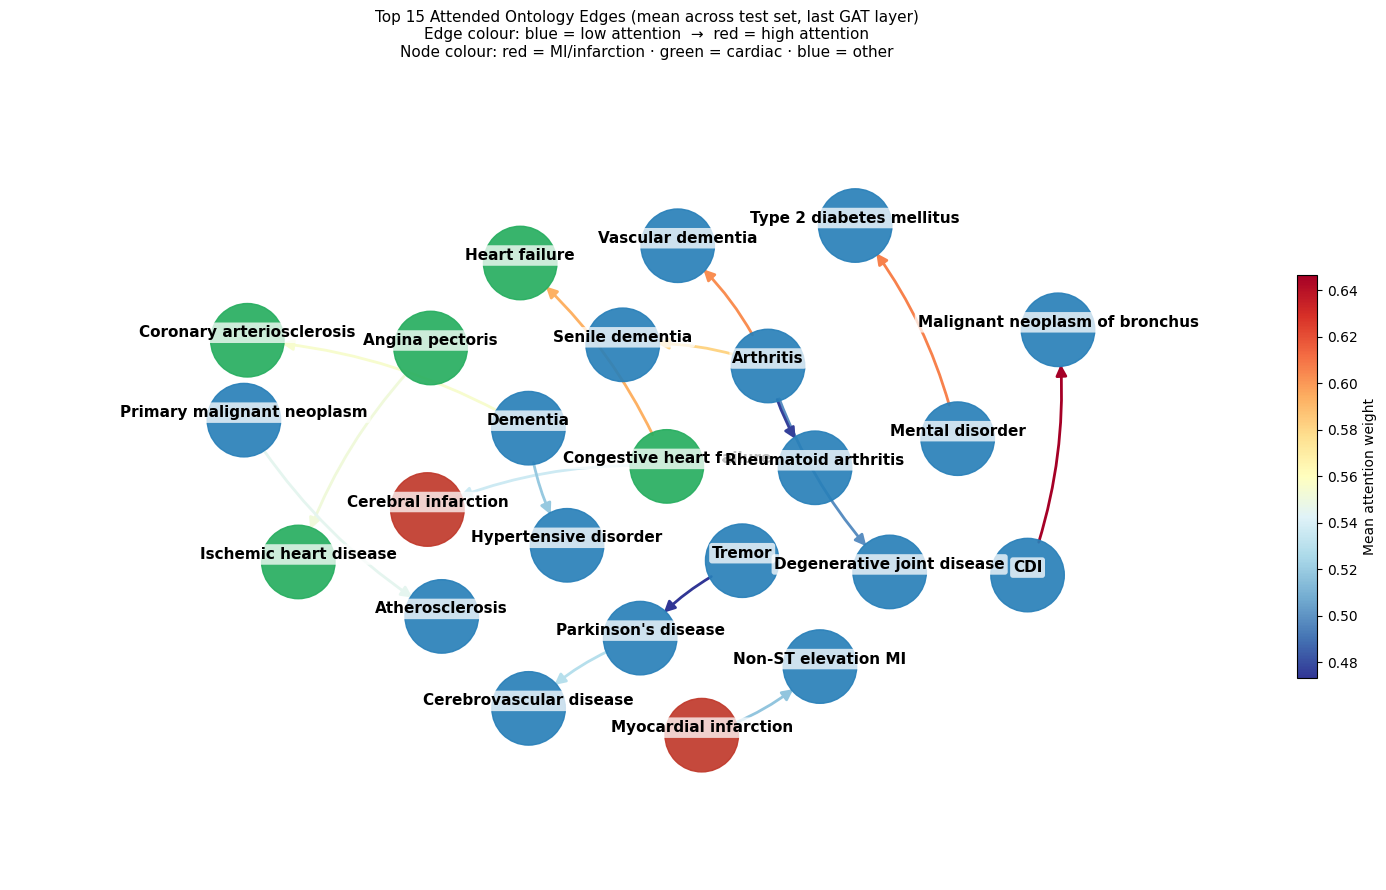

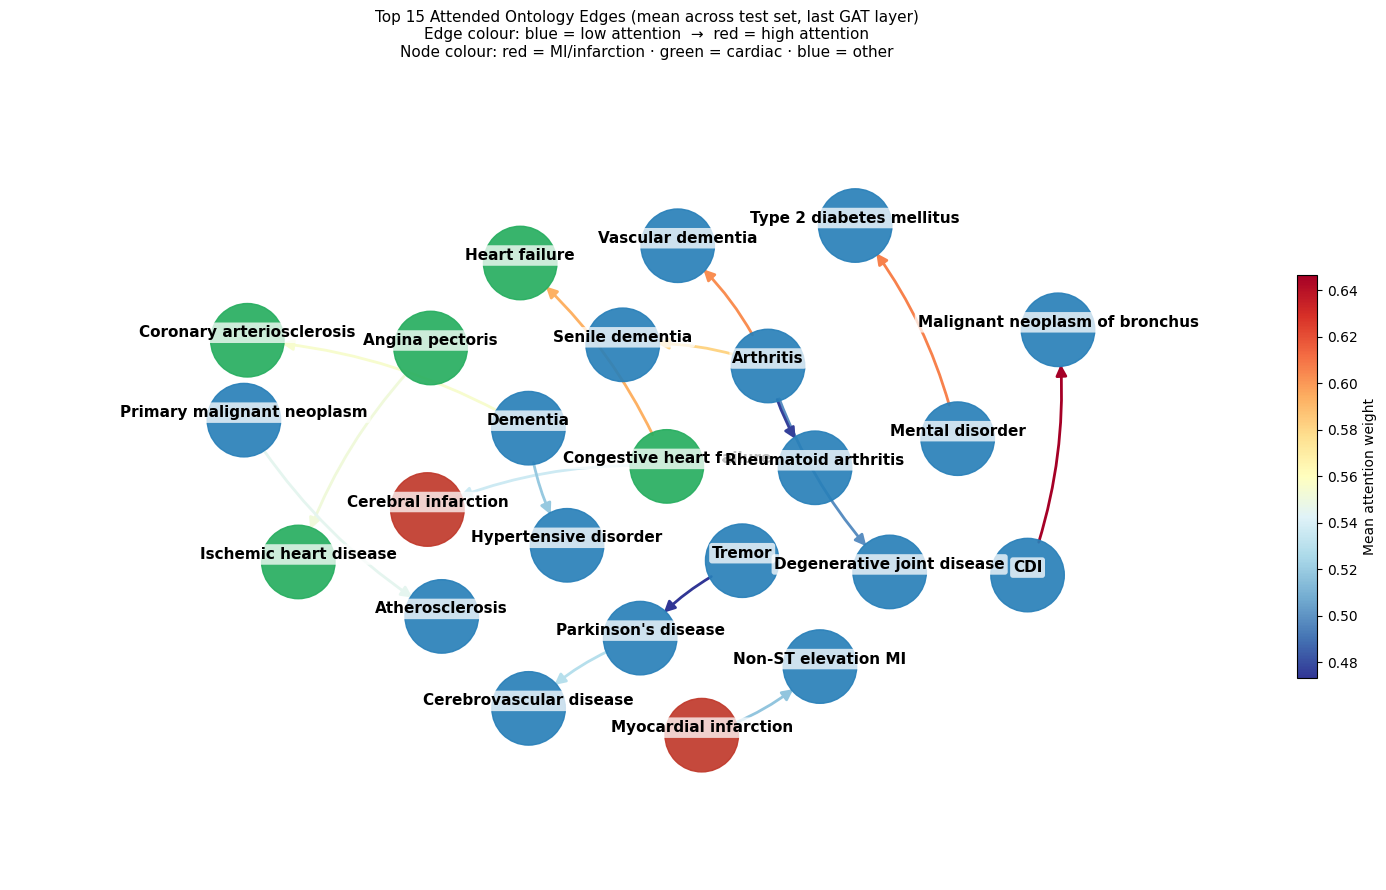

In [ ]:
# --- Visualise as a subgraph using shared helper ---
sub_attn = nx.DiGraph()
for _, row in attn_df.iterrows():
    sub_attn.add_edge(row["source"], row["target"], weight=row["attention"])

draw_ontology_graph(
    sub_attn,
    weight_key     = "weight",
    title          = (f"Top {top_k} Attended Ontology Edges "
                      f"(mean across test set, last GAT layer)\n"
                      f"Edge colour: blue = low attention  →  red = high attention\n"
                      f"Node colour: red = MI/infarction · green = cardiac · blue = other"),
    colorbar_label = "Mean attention weight",
    save_path      = PLOTS / "global_attention_graph.png",
)

## 3B. GNNExplainer – Local Explanations

For each patient of interest we find the **minimal subgraph of the ontology**
that is sufficient to reproduce the model's prediction.
We wrap CardioGNN in a thin adapter so it matches the signature expected by
`torch_geometric.explain.Explainer`.

In [ ]:
class OntologyExplainWrapper(nn.Module):
    """
    Thin wrapper so GNNExplainer can call model(x, edge_index).
    x      : [N_concepts, embed_dim]  (the raw SentenceTransformer embeddings)
    edge_index : [2, E]               (ontology, potentially masked by explainer)

    The patient-specific context (concept_seq, time_seq, …) is injected via
    closure — set `wrapper.set_patient(...)` before calling the explainer.
    """
    def __init__(self, cardiognn_model: CardioGNN):
        super().__init__()
        self.model = cardiognn_model
        self._c_seq  = None
        self._t_seq  = None
        self._l_seq  = None
        self._pmask  = None
        self._demo   = None

    def set_patient(self, c_seq, t_seq, l_seq, pmask, demo):
        self._c_seq  = c_seq.unsqueeze(0).to(DEVICE)    # [1, T]
        self._t_seq  = t_seq.unsqueeze(0).to(DEVICE)
        self._l_seq  = l_seq.unsqueeze(0).to(DEVICE)
        self._pmask  = pmask.unsqueeze(0).to(DEVICE)
        self._demo   = demo.unsqueeze(0).to(DEVICE)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        GNNExplainer calls forward(x, edge_index) and expects logits [1, n_classes]
        or [1] for binary. We re-use the ontology encoder with the given edge_index
        while keeping the patient context fixed.
        """
        # Temporarily replace ontology raw_embed with x (the explainer may perturb it)
        orig = self.model.ontology_enc.raw_embed
        self.model.ontology_enc.raw_embed = x

        logit = self.model(
            edge_index,
            self._c_seq, self._t_seq, self._l_seq,
            self._pmask, self._demo,
        )   # [1]

        self.model.ontology_enc.raw_embed = orig
        return logit.unsqueeze(-1)   # [1, 1] for binary classification


wrapper = OntologyExplainWrapper(model)

explainer = Explainer(
    model       = wrapper,
    algorithm   = GNNExplainer(epochs=200),
    explanation_type = "model",
    node_mask_type   = "attributes",
    edge_mask_type   = "object",
    model_config     = dict(
        mode          = "binary_classification",
        task_level    = "graph",
        return_type   = "raw",
    ),
)

print("GNNExplainer configured.")

GNNExplainer configured.


In [ ]:
def explain_patient(patient_idx: int, label_override=None):
    """
    Run GNNExplainer for one patient from the test set.
    Returns the Explanation object and prints a summary.
    """
    c = C_test[patient_idx]
    t = T_test[patient_idx]
    l = L_test[patient_idx]
    pm = PAD_MASK_test[patient_idx]
    dm = DEMO_test[patient_idx]

    wrapper.set_patient(c, t, l, pm, dm)

    # Build a PyG Data object for the full ontology graph
    x_feat = model.ontology_enc.raw_embed.detach().clone()  # [N, embed_dim]
    graph_data = Data(x=x_feat, edge_index=EDGE_INDEX).to(DEVICE)

    # GNNExplainer wants a graph-level target
    with torch.no_grad():
        logit = model(EDGE_INDEX,
                      c.unsqueeze(0).to(DEVICE),
                      t.unsqueeze(0).to(DEVICE),
                      l.unsqueeze(0).to(DEVICE),
                      pm.unsqueeze(0).to(DEVICE),
                      dm.unsqueeze(0).to(DEVICE))
        prob   = torch.sigmoid(logit).item()
        target = int(prob >= BEST_THR)

    explanation = explainer(
        graph_data.x, graph_data.edge_index,
        target=torch.tensor([target], device=DEVICE)
    )

    true_label = int(Y_test[patient_idx].item())
    print(f"\nPatient index : {patient_idx}")
    print(f"Predicted prob: {prob:.3f}  "
          f"({'MI risk' if prob >= BEST_THR else 'No MI risk'})  "
          f"True label: {'MI' if true_label else 'No MI'}")
    return explanation, prob, true_label


def plot_explanation(explanation, prob: float, true_label: int,
                     top_k: int = 8, title_suffix: str = ""):
    """
    Visualise the top-k edges from a GNNExplainer result using the shared
    draw_ontology_graph helper (black labels, colour-coded edges).
    """
    edge_mask = explanation.edge_mask.cpu().numpy()
    ei_local  = explanation.edge_index.cpu().numpy()

    top_ix = edge_mask.argsort()[-top_k * 3:][::-1]   # over-sample, filter below

    rows = []
    for i in top_ix:
        if edge_mask[i] < 1e-4:
            continue
        src_c = idx2concept.get(int(ei_local[0, i]))
        dst_c = idx2concept.get(int(ei_local[1, i]))
        if src_c is None or dst_c is None:
            continue
        rows.append({
            "source": id2name.get(src_c, f"ID:{src_c}"),
            "target": id2name.get(dst_c, f"ID:{dst_c}"),
            "mask"  : float(edge_mask[i]),
        })
        if len(rows) >= top_k:
            break

    if not rows:
        print("No edges with non-zero mask found.")
        return

    df  = pd.DataFrame(rows)
    sub = nx.DiGraph()
    for _, row in df.iterrows():
        sub.add_edge(row["source"], row["target"], weight=row["mask"])

    status  = "MI risk" if prob >= BEST_THR else "No MI"
    true_s  = "MI" if true_label else "No MI"
    title   = (f"GNNExplainer — local explanation\n"
               f"pred={prob:.2f} ({status})  ·  true={true_s}"
               + (f"  [{title_suffix}]" if title_suffix else ""))

    draw_ontology_graph(
        sub,
        weight_key     = "mask",
        title          = title,
        figsize        = (11, 7),
        colorbar_label = "GNNExplainer edge mask",
        save_path      = PLOTS / f"gnnexplainer_{title_suffix or 'patient'}.png",
    )
    return df

In [ ]:
# Find a true-positive and a true-negative for comparison
with torch.no_grad():
    logits_test = model(
        EDGE_INDEX,
        C_test.to(DEVICE), T_test.to(DEVICE), L_test.to(DEVICE),
        PAD_MASK_test.to(DEVICE), DEMO_test.to(DEVICE),
    )
probs_test = torch.sigmoid(logits_test).cpu().numpy()

true_pos_idx = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 1))[0]
true_neg_idx = np.where((probs_test <  BEST_THR) & (Y_test.numpy() == 0))[0]
false_pos_idx = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 0))[0]

print(f"True positives in test: {len(true_pos_idx)}")
print(f"True negatives in test: {len(true_neg_idx)}")

True positives in test: 21
True negatives in test: 71



Patient index : 37
Predicted prob: 0.523  (MI risk)  True label: MI


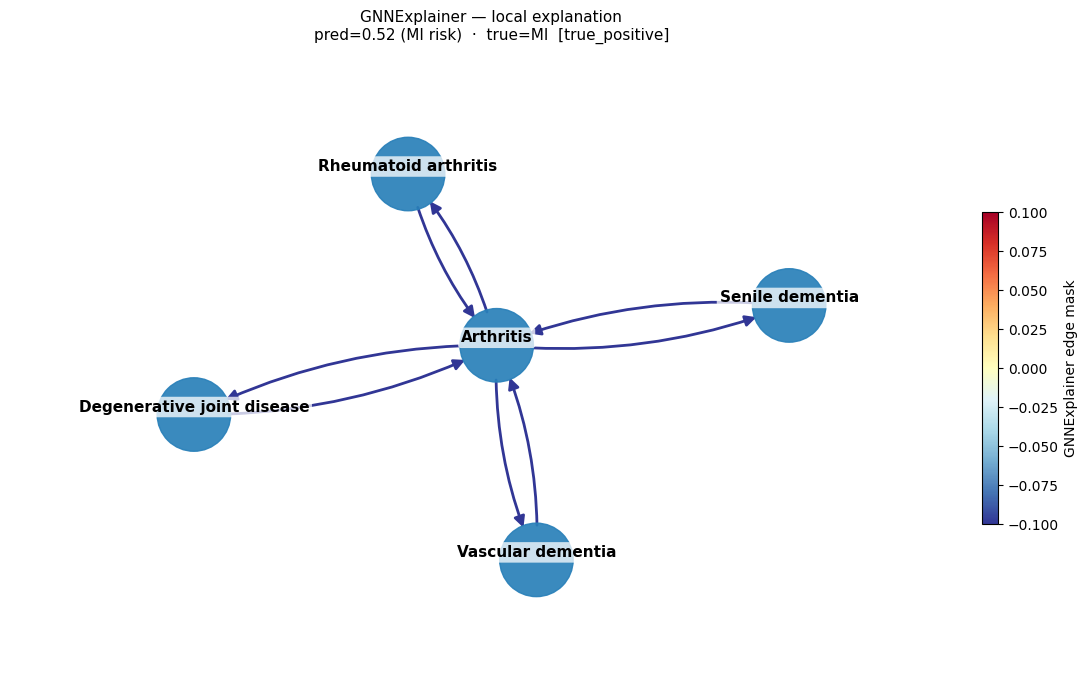

In [ ]:
# Explain a true positive
if len(true_pos_idx) > 0:
    exp_tp, prob_tp, lbl_tp = explain_patient(true_pos_idx[0])
    df_tp = plot_explanation(exp_tp, prob_tp, lbl_tp, title_suffix="true_positive")


Patient index : 0
Predicted prob: 0.542  (MI risk)  True label: No MI


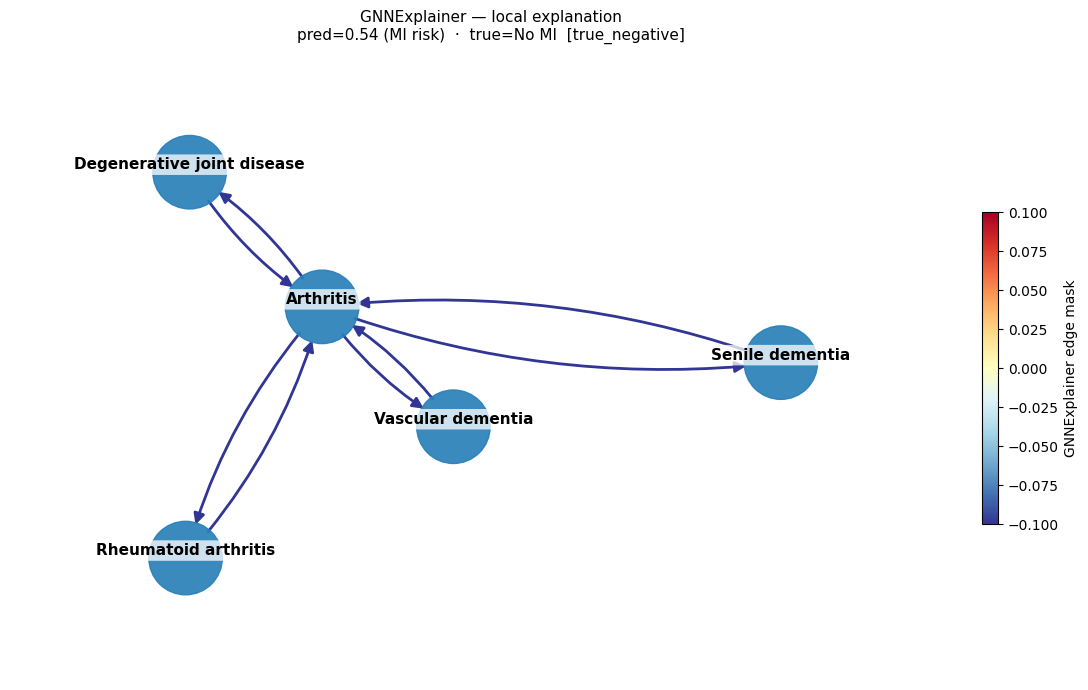

In [ ]:
# Explain a true negative
if len(false_pos_idx) > 0:
    exp_tn, prob_tn, lbl_tn = explain_patient(false_pos_idx[0])
    df_tn = plot_explanation(exp_tn, prob_tn, lbl_tn, title_suffix="true_negative")

## 3C. Sequence Attribution with Integrated Gradients

Complementing the graph-level explanation, Integrated Gradients tells us
which past medical events in the patient's history sequence contributed most
to the predicted risk score.

In [ ]:
class SequenceAttributionWrapper(nn.Module):
    """
    Wraps CardioGNN so that Integrated Gradients can differentiate through
    the embedding lookup by operating on *soft embeddings* (float inputs)
    rather than integer indices.

    Input:  concept_emb_seq  [B, T, H]  (differentiable proxy for concept_seqs)
    Output: logit            [B]
    """
    def __init__(self, cardiognn_model, edge_index):
        super().__init__()
        self.model      = cardiognn_model
        self.edge_index = edge_index

    def forward(self, concept_emb_seq: torch.Tensor,
                time_seqs: torch.Tensor,
                pad_mask: torch.Tensor,
                demo_data: torch.Tensor) -> torch.Tensor:
        # Bypass the embedding lookup — use directly the provided float tensor
        node_emb = self.model.ontology_enc(self.edge_index)
        # concept_emb_seq already is [B, T, H] — add time encoding on top
        x        = concept_emb_seq + self.model.time_enc(time_seqs)

        B, T, H  = x.shape
        positions = torch.arange(T, dtype=torch.float, device=x.device)
        pos_w     = torch.softmax(self.model.recency_alpha * positions, dim=0)
        pos_w     = pos_w.unsqueeze(0).unsqueeze(-1)
        real_mask = (~pad_mask).float().unsqueeze(-1)
        weighted  = x * pos_w * real_mask
        normaliser = (pos_w * real_mask).sum(1).clamp(min=1e-6)
        patient_rep = self.model.drop(weighted.sum(1) / normaliser)
        inp = torch.cat([patient_rep, demo_data], -1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.model.head(inp).squeeze(-1)


attr_wrapper = SequenceAttributionWrapper(model, EDGE_INDEX).to(DEVICE)
ig           = IntegratedGradients(attr_wrapper)

print("Integrated Gradients wrapper ready.")


def attribute_patient_sequence(patient_idx: int, n_steps: int = 50):
    """
    Compute IG attributions for each event in a patient's history.
    Returns a dict with event names and attribution magnitudes.
    """
    c   = C_test[patient_idx].to(DEVICE)       # [T]
    t   = T_test[patient_idx].unsqueeze(0).to(DEVICE)   # [1, T]
    pm  = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)  # [1, T]
    dm  = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    # Materialise concept embeddings for the patient's sequence
    node_emb    = model.ontology_enc(EDGE_INDEX).detach()       # [N, H]
    safe_c      = c.clamp(max=node_emb.shape[0] - 1)
    emb_seq     = node_emb[safe_c].unsqueeze(0).detach()        # [1, T, H]
    baseline    = torch.zeros_like(emb_seq)

    attributions, _ = ig.attribute(
        emb_seq, baseline,
        additional_forward_args=(t, pm, dm),
        n_steps=n_steps,
        return_convergence_delta=True,
        target=None,   # scalar output
    )

    # [1, T, H] → scalar importance per time step (L2 norm over H)
    importance = attributions.squeeze(0).norm(dim=-1).cpu().numpy()   # [T]
    mask_np    = pm.squeeze(0).cpu().numpy()    # True = padding

    # Build result: only real (non-padded) positions
    results = []
    for i, (imp, is_pad) in enumerate(zip(importance, mask_np)):
        if is_pad:
            continue
        concept_raw = c[i].item()
        if concept_raw >= NUM_CONCEPTS:
            continue
        concept_id = idx2concept[concept_raw]
        results.append({
            "position"   : i,
            "concept_id" : concept_id,
            "concept_name": id2name.get(concept_id, str(concept_id)),
            "attribution": float(imp),
        })

    return pd.DataFrame(results).sort_values("attribution", ascending=False)


def plot_ig_attribution(attr_df: pd.DataFrame,
                        prob: float, true_label: int,
                        title_suffix: str = ""):
    if attr_df.empty:
        print("No attributions to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, max(3, len(attr_df) * 0.55)))

    # Colour bars by magnitude: low → light salmon, high → deep red
    vals     = attr_df["attribution"].values
    norm_v   = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    colours  = plt.cm.Reds(0.35 + 0.6 * norm_v)   # range [0.35, 0.95] of Reds

    bars = ax.barh(attr_df["concept_name"], vals, color=colours)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("IG attribution magnitude", color="black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_edgecolor("black")

    status = "MI risk" if prob >= BEST_THR else "No MI"
    true_s = "MI" if true_label else "No MI"
    ax.set_title(
        f"Integrated Gradients — sequence attribution\n"
        f"pred={prob:.2f} ({status})  ·  true={true_s}"
        + (f"  [{title_suffix}]" if title_suffix else ""),
        color="black",
    )

    # Colourbar for magnitude scale
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                norm=plt.Normalize(vmin=vals.min(), vmax=vals.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.01,
                 label="Attribution magnitude")

    plt.tight_layout()
    plt.savefig(PLOTS / f"ig_attr_{title_suffix or 'patient'}.png",
                dpi=220, bbox_inches="tight")
    plt.show()

Integrated Gradients wrapper ready.


Patient 37  |  prob=0.523  label=MI
 position  concept_id concept_name  attribution
       49     4291025    Arthritis      0.33847


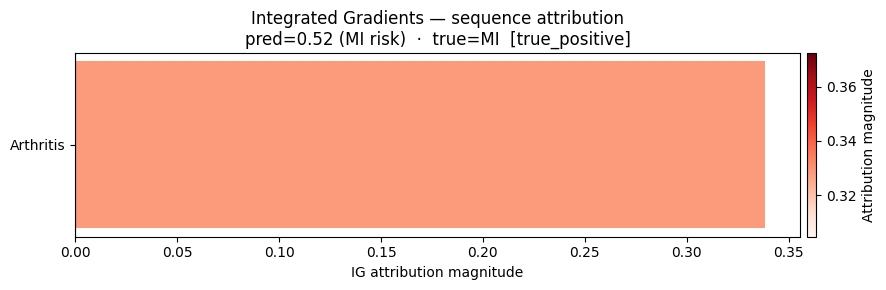

In [ ]:
# IG attribution for a true positive
if len(true_pos_idx) > 0:
    pi      = true_pos_idx[0]
    ig_df   = attribute_patient_sequence(pi)
    prob_pi = probs_test[pi]
    lbl_pi  = int(Y_test[pi].item())

    print(f"Patient {pi}  |  prob={prob_pi:.3f}  label={'MI' if lbl_pi else 'No MI'}")
    print(ig_df.to_string(index=False))
    plot_ig_attribution(ig_df, prob_pi, lbl_pi, title_suffix="true_positive")

Patient 5  |  prob=0.437  label=No MI
 position  concept_id               concept_name  attribution
       48      439392 Primary malignant neoplasm     0.189358
       49     4291025                  Arthritis     0.103426


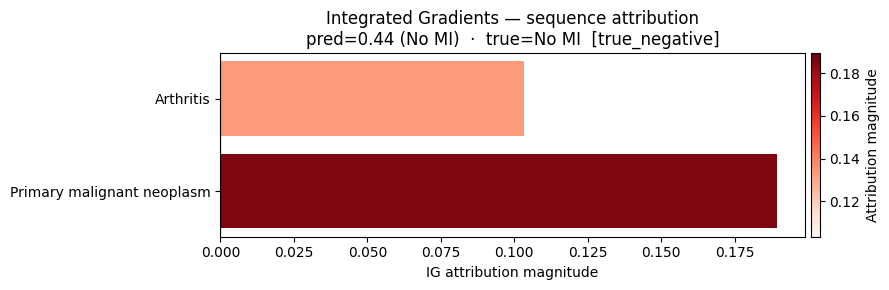

In [ ]:
# IG attribution for a true negative
if len(true_neg_idx) > 0:
    ni      = true_neg_idx[0]
    ig_df_n = attribute_patient_sequence(ni)
    prob_ni = probs_test[ni]
    lbl_ni  = int(Y_test[ni].item())

    print(f"Patient {ni}  |  prob={prob_ni:.3f}  label={'MI' if lbl_ni else 'No MI'}")
    print(ig_df_n.to_string(index=False))
    plot_ig_attribution(ig_df_n, prob_ni, lbl_ni, title_suffix="true_negative")

## 3D. Population-Level Event Attribution

Run IG for all true-positive test patients and aggregate:
which concepts **most consistently drive the MI prediction**?

In [ ]:
print("Running IG over all true-positive test patients...")

all_attr = {}
for pi in true_pos_idx:
    df_i = attribute_patient_sequence(pi)
    for _, row in df_i.iterrows():
        name = row["concept_name"]
        if name not in all_attr:
            all_attr[name] = []
        all_attr[name].append(row["attribution"])

# Mean + std attribution per concept (across patients who had that concept)
summary = pd.DataFrame([
    {"concept": k, "mean_attr": np.mean(v), "std_attr": np.std(v), "n": len(v)}
    for k, v in all_attr.items()
]).sort_values("mean_attr", ascending=False)

print("\nTop concepts by mean IG attribution (true positives):")
print(summary.head(12).to_string(index=False))

Running IG over all true-positive test patients...

Top concepts by mean IG attribution (true positives):
                   concept  mean_attr  std_attr  n
           Angina pectoris   0.362718  0.117444  9
                 Arthritis   0.211504  0.069304 17
           Mental disorder   0.133324  0.018063  2
Primary malignant neoplasm   0.121470  0.006613  2
                       CDI   0.113134  0.024995  4
                  Dementia   0.096175  0.000000  1


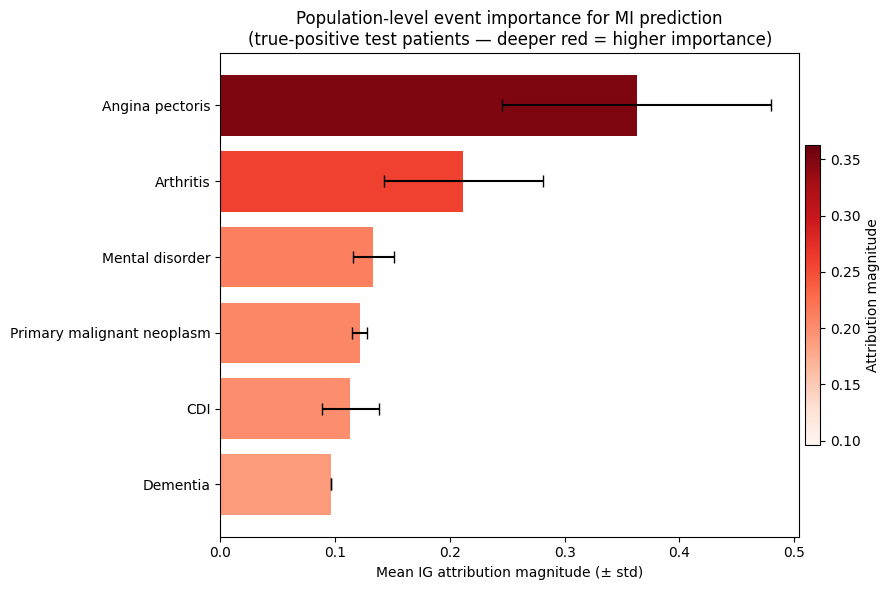

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
top_s    = summary.head(12).iloc[::-1]   # reverse so highest is at top
vals_pop = top_s["mean_attr"].values
norm_pop = (vals_pop - vals_pop.min()) / (vals_pop.max() - vals_pop.min() + 1e-9)
colours_pop = plt.cm.Reds(0.35 + 0.6 * norm_pop)

ax.barh(top_s["concept"], vals_pop,
        xerr=top_s["std_attr"].values, color=colours_pop, capsize=4)
ax.set_xlabel("Mean IG attribution magnitude (± std)", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
ax.set_title(
    "Population-level event importance for MI prediction\n"
    "(true-positive test patients — deeper red = higher importance)",
    color="black",
)

sm_pop = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                norm=plt.Normalize(vmin=vals_pop.min(),
                                                   vmax=vals_pop.max()))
sm_pop.set_array([])
plt.colorbar(sm_pop, ax=ax, fraction=0.025, pad=0.01, label="Attribution magnitude")

plt.tight_layout()
plt.savefig(PLOTS / "population_ig_attribution.png", dpi=220, bbox_inches="tight")
plt.show()

## 3E. Sensitivity Analysis (SA) — Gradient-based

**Taxonomy position**: Post-hoc → Gradient-based (alongside IG, Guided-BP, Grad-CAM)

SA computes the gradient of the output logit with respect to the input concept
embeddings directly at the observed input point — **no baseline integration**.
This makes it faster than IG and captures the local gradient landscape rather
than the path-integrated attribution. Comparing SA vs IG reveals whether the
attribution is stable (both agree) or input-dependent (they diverge).

| Method | Baseline needed | What it measures |
|---|---|---|
| **IG** | Yes (zero vector) | Path-integrated attribution from baseline to input |
| **SA** | No | Local gradient magnitude at the observed input |

In [ ]:
def sensitivity_analysis(patient_idx: int):
    """
    Compute Sensitivity Analysis attributions for one patient.
    SA = L2 norm of d(logit)/d(embedding) evaluated at the observed input.
    Returns a DataFrame identical in structure to attribute_patient_sequence().
    """
    c   = C_test[patient_idx].to(DEVICE)
    t   = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm  = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm  = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    node_emb = model.ontology_enc(EDGE_INDEX).detach()
    safe_c   = c.clamp(max=node_emb.shape[0] - 1)
    emb_seq  = node_emb[safe_c].unsqueeze(0)        # [1, T, H]
    emb_seq.requires_grad_(True)

    # Forward pass through the SequenceAttributionWrapper (differentiable)
    logit = attr_wrapper(emb_seq, t, pm, dm)         # scalar
    logit.backward()

    # SA importance = L2 norm of gradient per time step
    grad      = emb_seq.grad.squeeze(0)              # [T, H]
    importance = grad.norm(dim=-1).detach().cpu().numpy()  # [T]
    mask_np   = pm.squeeze(0).cpu().numpy()

    results = []
    for i, (imp, is_pad) in enumerate(zip(importance, mask_np)):
        if is_pad:
            continue
        concept_raw = c[i].item()
        if concept_raw >= NUM_CONCEPTS:
            continue
        concept_id = idx2concept[concept_raw]
        results.append({
            "position"    : i,
            "concept_id"  : concept_id,
            "concept_name": id2name.get(concept_id, str(concept_id)),
            "sa_score"    : float(imp),
        })

    return pd.DataFrame(results).sort_values("sa_score", ascending=False)


def plot_sa_ig_comparison(patient_idx: int, prob: float, true_label: int,
                          title_suffix: str = ""):
    """
    Side-by-side bar chart comparing SA and IG attributions for the same patient.
    Helps assess whether gradient signal is stable (SA ≈ IG) or path-dependent.
    """
    sa_df = sensitivity_analysis(patient_idx)
    ig_df = attribute_patient_sequence(patient_idx)

    # Merge on concept name
    merged = sa_df[["concept_name", "sa_score"]].merge(
        ig_df[["concept_name", "attribution"]],
        on="concept_name", how="outer"
    ).fillna(0).sort_values("sa_score", ascending=True)

    if merged.empty:
        print("No attributions to compare.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, max(3, len(merged) * 0.6 + 1)),
                              sharey=True)

    # SA bars
    vals_sa   = merged["sa_score"].values
    norm_sa   = (vals_sa - vals_sa.min()) / (vals_sa.max() - vals_sa.min() + 1e-9)
    axes[0].barh(merged["concept_name"], vals_sa,
                 color=plt.cm.Blues(0.35 + 0.6 * norm_sa))
    axes[0].set_xlabel("SA gradient magnitude", color="black")
    axes[0].set_title("Sensitivity Analysis\n(local gradient at input)", color="black")
    axes[0].tick_params(colors="black")

    # IG bars
    vals_ig   = merged["attribution"].values
    norm_ig   = (vals_ig - vals_ig.min()) / (vals_ig.max() - vals_ig.min() + 1e-9)
    axes[1].barh(merged["concept_name"], vals_ig,
                 color=plt.cm.Reds(0.35 + 0.6 * norm_ig))
    axes[1].set_xlabel("IG attribution magnitude", color="black")
    axes[1].set_title("Integrated Gradients\n(path-integrated from baseline)", color="black")
    axes[1].tick_params(colors="black")

    status = "MI risk" if prob >= BEST_THR else "No MI"
    true_s = "MI" if true_label else "No MI"
    fig.suptitle(
        f"SA vs IG comparison  |  pred={prob:.2f} ({status})  ·  true={true_s}"
        + (f"  [{title_suffix}]" if title_suffix else ""),
        fontsize=11, color="black",
    )
    plt.tight_layout()
    plt.savefig(PLOTS / f"sa_ig_comparison_{title_suffix or 'patient'}.png",
                dpi=220, bbox_inches="tight")
    plt.show()
    return merged

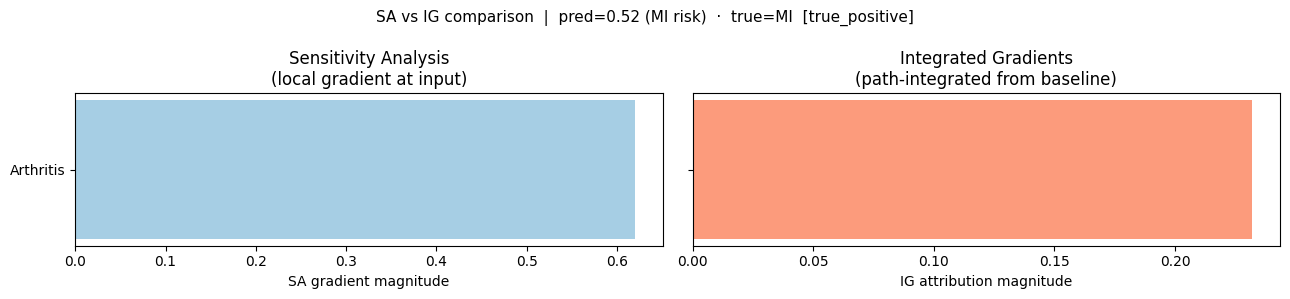

SA vs IG (true positive):
concept_name  sa_score  attribution
   Arthritis  0.619437     0.231976


In [ ]:
# SA vs IG comparison for the true positive
if len(true_pos_idx) > 0:
    pi     = true_pos_idx[0]
    merged_tp = plot_sa_ig_comparison(pi, probs_test[pi], int(Y_test[pi].item()),
                                      title_suffix="true_positive")
    print("SA vs IG (true positive):")
    print(merged_tp.to_string(index=False))

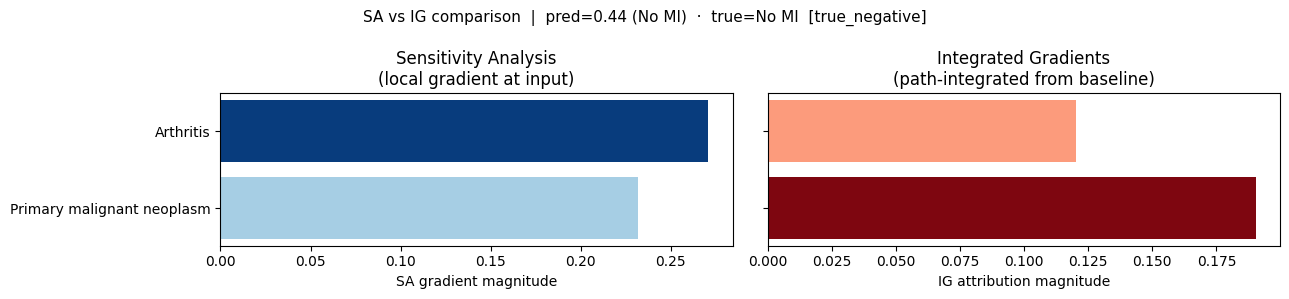

SA vs IG (true negative):
              concept_name  sa_score  attribution
Primary malignant neoplasm  0.232020     0.190271
                 Arthritis  0.270881     0.120306


In [ ]:
# SA vs IG comparison for the true negative
if len(true_neg_idx) > 0:
    ni     = true_neg_idx[0]
    merged_tn = plot_sa_ig_comparison(ni, probs_test[ni], int(Y_test[ni].item()),
                                      title_suffix="true_negative")
    print("SA vs IG (true negative):")
    print(merged_tn.to_string(index=False))

## 3F. Counterfactual Explanation — Edge Perturbation

**Taxonomy position**: Counterfactual → Perturbation-based (CF-GNNExplainer family)

A counterfactual explanation answers: **"What is the minimal change to the
ontology graph that would flip this patient's prediction from MI → No MI?"**

This is the most clinically actionable explanation type:
- **Factual** (GNNExplainer): "These edges made the model predict MI"
- **Counterfactual** (here): "If we removed *these* ontology relationships,
  the model would no longer predict MI"

### Algorithm
For each edge in the ontology graph, we compute how much the predicted risk
drops when that edge is removed (zeroed out from `EDGE_INDEX`). The edges
whose removal causes the largest drop are the **counterfactual-critical edges**.

This is a greedy single-edge perturbation — a simplified version of
CF-GNNExplainer that is exact (no approximation) for small graphs like ours.

In [ ]:
@torch.no_grad()
def counterfactual_edge_importance(patient_idx: int) -> pd.DataFrame:
    """
    For every ontology edge, compute Δprob = prob(original) − prob(edge removed).
    Positive Δprob = removing this edge DECREASES MI risk (counterfactual-critical).
    Negative Δprob = removing this edge INCREASES MI risk (protective edge).

    Returns a DataFrame sorted by Δprob descending.
    """
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    # Baseline probability with full graph
    logit_orig = model(EDGE_INDEX, c, t, l, pm, dm)
    prob_orig  = torch.sigmoid(logit_orig).item()

    ei_np = EDGE_INDEX.cpu().numpy()
    n_edges = EDGE_INDEX.shape[1]

    rows = []
    for i in range(n_edges):
        # Build edge_index with edge i removed
        mask = torch.ones(n_edges, dtype=torch.bool, device=DEVICE)
        mask[i] = False
        ei_perturbed = EDGE_INDEX[:, mask]

        logit_pert = model(ei_perturbed, c, t, l, pm, dm)
        prob_pert  = torch.sigmoid(logit_pert).item()

        delta = prob_orig - prob_pert   # positive = this edge increased MI risk

        src_raw = int(ei_np[0, i])
        dst_raw = int(ei_np[1, i])
        src_c   = idx2concept.get(src_raw)
        dst_c   = idx2concept.get(dst_raw)
        if src_c is None or dst_c is None:
            continue

        rows.append({
            "edge_idx"  : i,
            "source"    : id2name.get(src_c, f"ID:{src_c}"),
            "target"    : id2name.get(dst_c, f"ID:{dst_c}"),
            "prob_orig" : prob_orig,
            "prob_perturbed": prob_pert,
            "delta_prob": delta,
        })

    return pd.DataFrame(rows).sort_values("delta_prob", ascending=False)


def plot_counterfactual(cf_df: pd.DataFrame, prob: float, true_label: int,
                        top_k: int = 10, title_suffix: str = ""):
    """
    Bar chart of Δprob per edge.
    Positive bars (red)  = counterfactual-critical: removing this edge lowers MI risk.
    Negative bars (blue) = protective: removing this edge would RAISE MI risk.
    """
    if cf_df.empty:
        print("No counterfactual data.")
        return

    # Take top_k positive and top_k negative
    pos_rows = cf_df[cf_df["delta_prob"] > 0].head(top_k)
    neg_rows = cf_df[cf_df["delta_prob"] < 0].tail(top_k)
    plot_df  = pd.concat([neg_rows, pos_rows]).copy()
    plot_df["edge_label"] = plot_df["source"] + "  →  " + plot_df["target"]
    plot_df = plot_df.sort_values("delta_prob")

    colours = ["#c0392b" if d > 0 else "#2980b9"
               for d in plot_df["delta_prob"]]

    fig, ax = plt.subplots(figsize=(13, max(5, len(plot_df) * 0.6 + 1)))
    ax.barh(plot_df["edge_label"], plot_df["delta_prob"], color=colours)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Δ predicted MI probability when edge is removed", color="black", fontsize=11)
    ax.tick_params(colors="black", labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")

    status = "MI risk" if prob >= BEST_THR else "No MI"
    true_s = "MI" if true_label else "No MI"
    ax.set_title(
        f"Counterfactual edge perturbation\n"
        f"pred={prob:.2f} ({status})  ·  true={true_s}\n"
        f"Red = removing this edge LOWERS MI risk  |  "
        f"Blue = removing this edge RAISES MI risk"
        + (f"  [{title_suffix}]" if title_suffix else ""),
        color="black", fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(PLOTS / f"counterfactual_{title_suffix or 'patient'}.png",
                dpi=220, bbox_inches="tight")
    plt.show()

    # Also visualise the top counterfactual-critical subgraph
    top_cf = cf_df[cf_df["delta_prob"] > 0].head(top_k)
    if not top_cf.empty:
        sub_cf = nx.DiGraph()
        for _, row in top_cf.iterrows():
            sub_cf.add_edge(row["source"], row["target"],
                            weight=float(row["delta_prob"]))
        draw_ontology_graph(
            sub_cf,
            weight_key     = "weight",
            title          = (f"Counterfactual-critical ontology edges\n"
                              f"Removing any red edge would most reduce MI risk\n"
                              f"pred={prob:.2f} ({status})  ·  true={true_s}"
                              + (f"  [{title_suffix}]" if title_suffix else "")),
            figsize        = (14, 9),
            colorbar_label = "Δ prob if edge removed",
            save_path      = PLOTS / f"counterfactual_graph_{title_suffix or 'patient'}.png",
        )
    return plot_df

Top counterfactual-critical edges (true positive):
                    source                target  prob_orig  prob_perturbed  delta_prob
                  Dementia   Alzheimer's disease   0.527982        0.392644    0.135338
                 Arthritis  Rheumatoid arthritis   0.527982        0.410445    0.117537
  Type 2 diabetes mellitus       Mental disorder   0.527982        0.419763    0.108219
                Chest pain       Angina pectoris   0.527982        0.422799    0.105183
           Senile dementia             Arthritis   0.527982        0.422969    0.105013
       Non-ST elevation MI Myocardial infarction   0.527982        0.426584    0.101398
Degenerative joint disease             Arthritis   0.527982        0.436788    0.091195
           Unstable angina       Angina pectoris   0.527982        0.449675    0.078307
                 Arthritis     Vascular dementia   0.527982        0.462555    0.065428
           Angina pectoris       Unstable angina   0.527982        0.

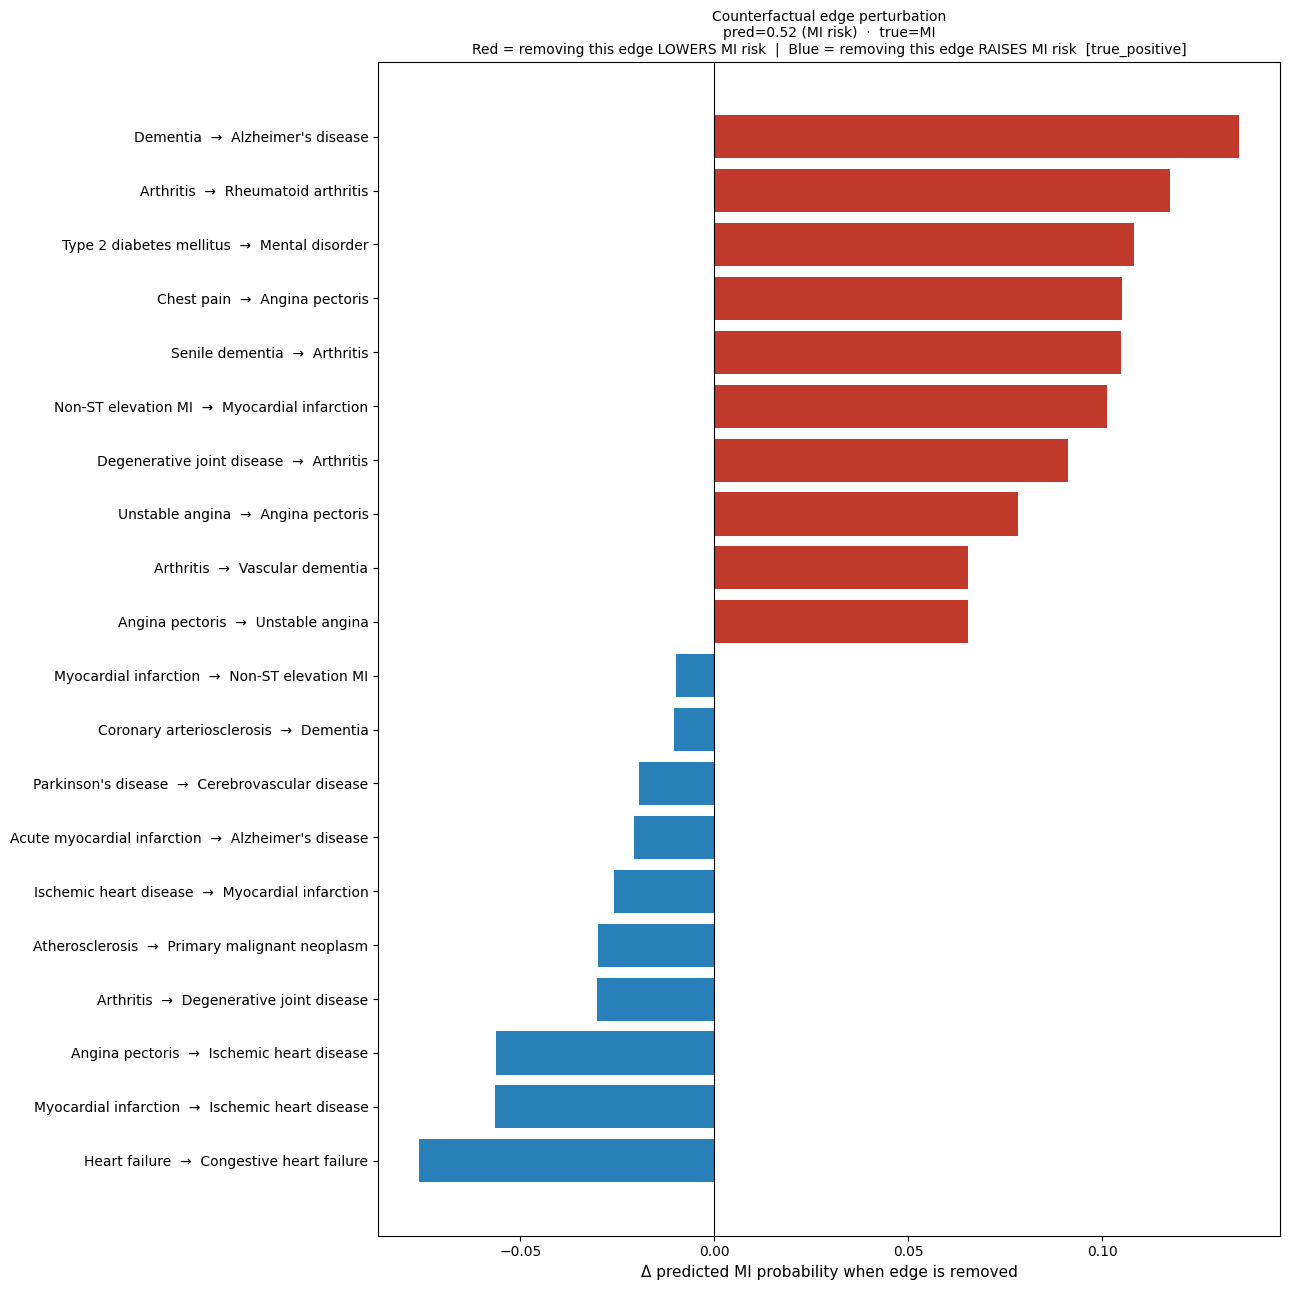

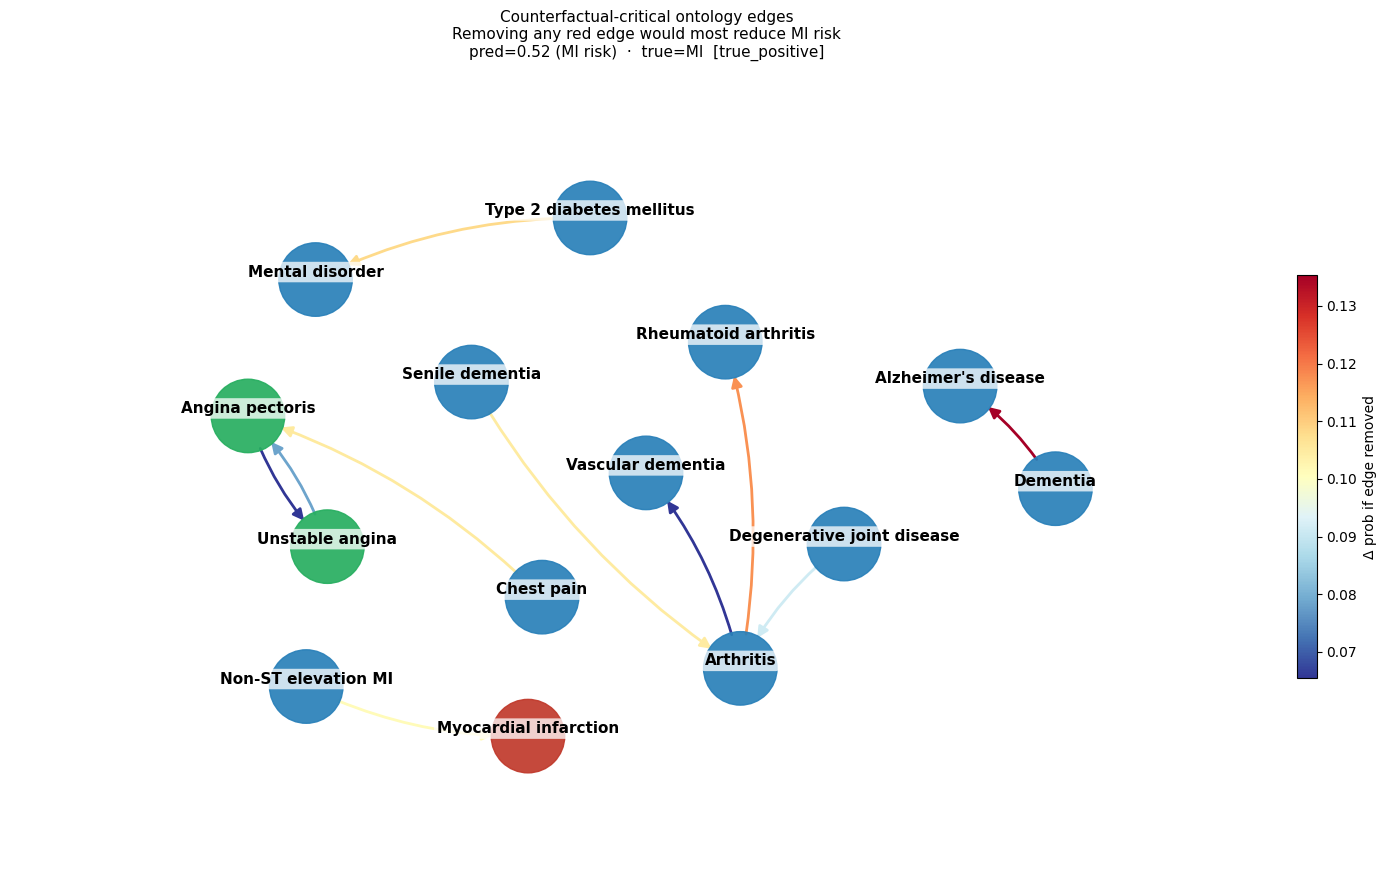

In [ ]:
# Counterfactual for the true positive patient
if len(true_pos_idx) > 0:
    pi    = true_pos_idx[0]
    cf_tp = counterfactual_edge_importance(pi)
    print("Top counterfactual-critical edges (true positive):")
    print(cf_tp.head(10)[["source","target","prob_orig","prob_perturbed","delta_prob"]]
          .to_string(index=False))
    plot_counterfactual(cf_tp, probs_test[pi], int(Y_test[pi].item()),
                        title_suffix="true_positive")

False positives in test: 193

Top counterfactual-critical edges (false positive):
                        source                    target  prob_orig  prob_perturbed  delta_prob
      Congestive heart failure       Cerebral infarction   0.472536        0.372795    0.099741
         Myocardial infarction    Ischemic heart disease   0.472536        0.435253    0.037283
      Congestive heart failure             Heart failure   0.472536        0.450235    0.022301
                        Tremor       Parkinson's disease   0.472536        0.456061    0.016475
           Parkinson's disease                    Tremor   0.472536        0.457972    0.014564
   Acute myocardial infarction       Alzheimer's disease   0.472536        0.460384    0.012152
               Unstable angina           Angina pectoris   0.472536        0.465329    0.007207
Malignant neoplasm of bronchus                       CDI   0.472536        0.470437    0.002099
    Primary malignant neoplasm           Atheroscleros

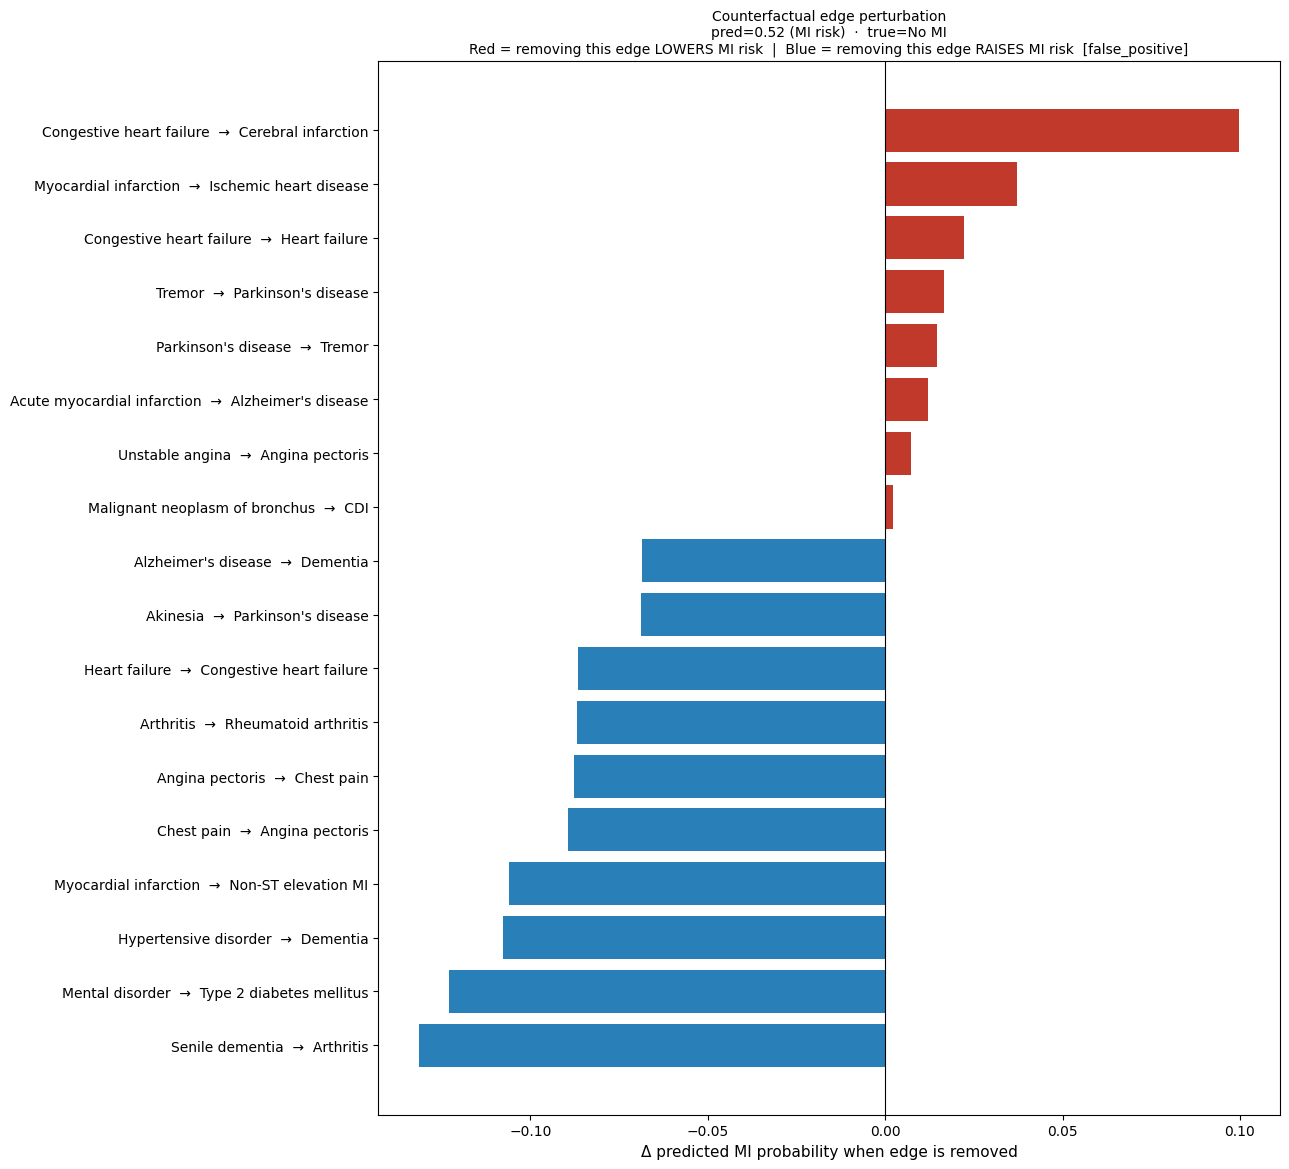

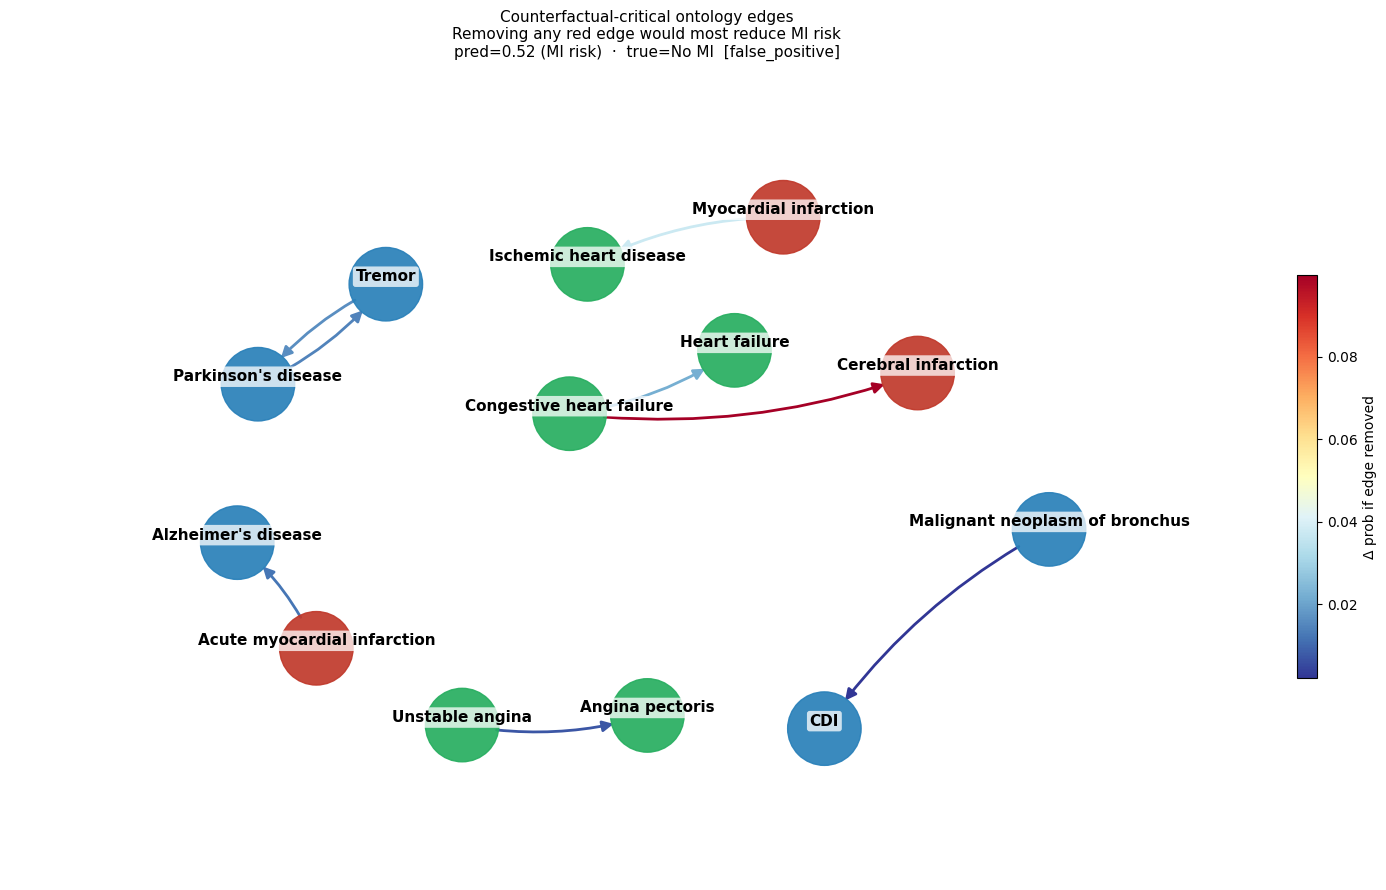

In [ ]:
# Counterfactual for a false positive (model predicted MI but was wrong) if available
false_pos_idx = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 0))[0]
print(f"False positives in test: {len(false_pos_idx)}")

if len(false_pos_idx) > 0:
    fp    = false_pos_idx[0]
    cf_fp = counterfactual_edge_importance(fp)
    print("\nTop counterfactual-critical edges (false positive):")
    print(cf_fp.head(10)[["source","target","prob_orig","prob_perturbed","delta_prob"]]
          .to_string(index=False))
    plot_counterfactual(cf_fp, probs_test[fp], int(Y_test[fp].item()),
                        title_suffix="false_positive")

## Summary

| Output file | Method family | Content |
|---|---|---|
| `global_attention_graph.png` | Structural (self-interpretable) | Top attended ontology edges across all test patients |
| `gnnexplainer_true_positive.png` | Post-hoc · Perturbation | Minimal explanatory subgraph — true positive |
| `gnnexplainer_true_negative.png` | Post-hoc · Perturbation | Minimal explanatory subgraph — true negative |
| `ig_attr_true_positive.png` | Post-hoc · Gradient-based | Integrated Gradients sequence attribution — true positive |
| `ig_attr_true_negative.png` | Post-hoc · Gradient-based | Integrated Gradients sequence attribution — true negative |
| `population_ig_attribution.png` | Post-hoc · Gradient-based | Aggregate IG importance across all true positives |
| `sa_ig_comparison_true_positive.png` | Post-hoc · Gradient-based | SA vs IG side-by-side — true positive |
| `sa_ig_comparison_true_negative.png` | Post-hoc · Gradient-based | SA vs IG side-by-side — true negative |
| `counterfactual_true_positive.png` | Counterfactual · Perturbation | Δprob per edge removed — true positive |
| `counterfactual_graph_true_positive.png` | Counterfactual · Perturbation | Critical subgraph for flipping prediction |
| `counterfactual_false_positive.png` | Counterfactual · Perturbation | Δprob per edge removed — false positive |